##   просчет роллов в артах


In [1]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import random

from scipy.optimize import curve_fit
from scipy.stats import chisquare, power_divergence, norm
from math import isclose
import math


%matplotlib inline

In [2]:
# import sys
# !{sys.executable} -m pip install scipy
# import matplotlib
# print(matplotlib.__version__)

### Constants

In [3]:
n_exp = 500
n_discs = 5000
n_substats = 4
#random.seed(a=2, version=2)

stats_map = {
            "atk": 0,
            "atk%": 1,
            "hp": 2, 
            "hp%": 3,
            "def": 4,
            "def%": 5,
            "CR": 6,
            "CD": 7,
            "pen": 8,
            "AP": 9,
            "pen%": 10,
            "AM": 11,
            "impact": 12,
            "ER": 13,
            "Ether DMG": 14,
            "Electric DMG": 15,
            "Physical DMG": 16,
            "Ice DMG": 17,
            "Fire DMG": 18
            }

sub_stats_names = ["atk", "atk%", "hp", "hp%", "def", "def%", "CR", "CD", "pen", "AP"]
sub_stats_count = len(sub_stats_names) # 10
sub_stats_indexes = list(range(10))
sub_stats_value = [19, 3, 112, 3, 15, 4.8, 2.4, 4.8, 9, 9]
sub_stats_weights = [98,
90,
103,
113,
112,
131,
116,
104,
107,
97]

disc_4_pop = [stats_map["atk%"],
              stats_map["hp%"],
              stats_map["def%"],
              stats_map["CR"],
              stats_map["CD"],
              stats_map["AP"]
             ]
disc_4_weights = [1, 1, 1, 1, 1, 1]

disc_5_pop = [stats_map["atk%"],
              stats_map["hp%"],
              stats_map["def%"],
              stats_map["pen%"],
              stats_map["Ether DMG"],
              stats_map["Electric DMG"],
              stats_map["Physical DMG"],
              stats_map["Ice DMG"],
              stats_map["Fire DMG"]
             ]
disc_5_weights = [2, 2, 2, 1, 1, 1, 1, 1, 1]

disc_6_pop = [stats_map["atk%"],
              stats_map["hp%"],
              stats_map["def%"],
              stats_map["AM"],
              stats_map["impact"],
              stats_map["ER"]
             ]
disc_6_weights = [2, 2, 2, 2, 2, 1]

count_rolls = [4, 4, 4, 4, 5]



In [33]:
sub_by_main_stat = [
    [sub_stats_indexes.copy(), sub_stats_weights.copy()]
    for _ in range(len(stats_map))
]
for i in range(10):
    del sub_by_main_stat[i][0][i]
    del sub_by_main_stat[i][1][i]
sub_by_main_stat

[[[1, 2, 3, 4, 5, 6, 7, 8, 9], [90, 103, 113, 112, 131, 116, 104, 107, 97]],
 [[0, 2, 3, 4, 5, 6, 7, 8, 9], [98, 103, 113, 112, 131, 116, 104, 107, 97]],
 [[0, 1, 3, 4, 5, 6, 7, 8, 9], [98, 90, 113, 112, 131, 116, 104, 107, 97]],
 [[0, 1, 2, 4, 5, 6, 7, 8, 9], [98, 90, 103, 112, 131, 116, 104, 107, 97]],
 [[0, 1, 2, 3, 5, 6, 7, 8, 9], [98, 90, 103, 113, 131, 116, 104, 107, 97]],
 [[0, 1, 2, 3, 4, 6, 7, 8, 9], [98, 90, 103, 113, 112, 116, 104, 107, 97]],
 [[0, 1, 2, 3, 4, 5, 7, 8, 9], [98, 90, 103, 113, 112, 131, 104, 107, 97]],
 [[0, 1, 2, 3, 4, 5, 6, 8, 9], [98, 90, 103, 113, 112, 131, 116, 107, 97]],
 [[0, 1, 2, 3, 4, 5, 6, 7, 9], [98, 90, 103, 113, 112, 131, 116, 104, 97]],
 [[0, 1, 2, 3, 4, 5, 6, 7, 8], [98, 90, 103, 113, 112, 131, 116, 104, 107]],
 [[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
  [98, 90, 103, 113, 112, 131, 116, 104, 107, 97]],
 [[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
  [98, 90, 103, 113, 112, 131, 116, 104, 107, 97]],
 [[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
  [98, 90, 103, 113, 112, 131, 

In [34]:
disc_1_3_main_stat = {
            1: stats_map["hp"],
            2: stats_map["atk"],
            3: stats_map["def"]
            }
disc_4_6_main_stat = {
            4: [disc_4_pop, disc_4_weights],
            5: [disc_5_pop, disc_5_weights],
            6: [disc_6_pop, disc_6_weights]
            }

### Functions

In [36]:
def weighted_sample_no_replacement(population, weights, k):
    population = population[:]  # копии
    weights = weights[:]
    result = []
    for _ in range(k):
        choice = random.choices(population, weights=weights, k=1)[0]
        idx = population.index(choice)
        result.append(choice)
        # убираем выбранный элемент
        population.pop(idx)
        weights.pop(idx)
    return result

def get_main_stat(disc_num):
    if disc_num < 4:
        return disc_1_3_main_stat[disc_num]
    population, weights = disc_4_6_main_stat[disc_num]
    return random.choices(population=population, weights=weights)[0]

def get_sub_stats(main_stat):
    population, weights = sub_by_main_stat[main_stat]
    #sub_stats = random.sample(
    #    population=population, 
    #    k=4, 
    #    counts=weights  # Python 3.11+ поддерживает counts
    #)
    sub_stats = weighted_sample_no_replacement(population, weights, n_substats)
    
    sub_rolls = random.choices(population=list(range(n_substats)), k = random.choice(count_rolls))
    count_sub_rolls = np.bincount(sub_rolls, minlength=n_substats) + 1
    
    return sub_stats, count_sub_rolls

def get_main_and_sub_stats(disc_num):
    main_stat = get_main_stat(disc_num)
    (sub_stats, sub_rolls) = get_sub_stats(main_stat)
    return main_stat, sub_stats, sub_rolls

In [37]:
def generate_discs_arr():
    result = []
    discs_numbers = random.choices(population=[1,2,3,4,5,6], k=n_discs)
    discs = list(map(get_main_and_sub_stats, discs_numbers))

    max_useful_by_disc = np.zeros(7, dtype=int)
    max_useful = 0

    for i in range(n_discs):
        discs_number = discs_numbers[i]
        main_stat, sub_stats, sub_rolls = discs[i]
        if usefull_main_stats[discs_number] != main_stat:
            result.append(max_useful)
            continue
        count_useful = 0
        for j in range(n_substats):
            if sub_stats[j] in usefull_sub_stats:
                count_useful += sub_rolls[j]
        if max_useful_by_disc[discs_number] < count_useful:
            max_useful +=  count_useful - max_useful_by_disc[discs_number]
            max_useful_by_disc[discs_number] = count_useful
        
        result.append(max_useful)
    return np.array(result)

In [41]:
def build_one_curve():
    avg_curve = generate_discs_arr()

    plt.plot(avg_curve)
    plt.xlabel("Число сгенерированных дисков")
    plt.ylabel("Средний максимум полезных проков")
    plt.grid(True)
    plt.show()

def build_multi_curve():
    avg_curve = np.zeros(n_discs, dtype=float)
    
    for _ in range(n_exp):
        avg_curve += generate_discs_arr()
    avg_curve /= n_exp 
    
    
    plt.plot(avg_curve)
    plt.xlabel("Число сгенерированных дисков")
    plt.ylabel("Средний максимум полезных проков")
    plt.grid(True)
    plt.show()

    # Методы анализа «точки насыщения»
    def logistic(x, L, k, x0):
        return L / (1 + np.exp(-k*(x-x0)))
    
    x = np.arange(len(avg_curve))
    y = avg_curve
    popt, _ = curve_fit(logistic, x, y, p0=[max(y), 0.001, 1000])
    # popt = параметры L (максимум), k (наклон), x0 (середина)
    
    L, k, x0 = popt
    saturation_point = np.log(19)/k + x0  # 95% от L
    print("Рекомендуем остановиться примерно на артефакте с числом пользы", round(avg_curve[int(saturation_point)]),
          "после", math.ceil(saturation_point), "дисков")
    return avg_curve

### Генерация дисков для критовозависимых персонажей

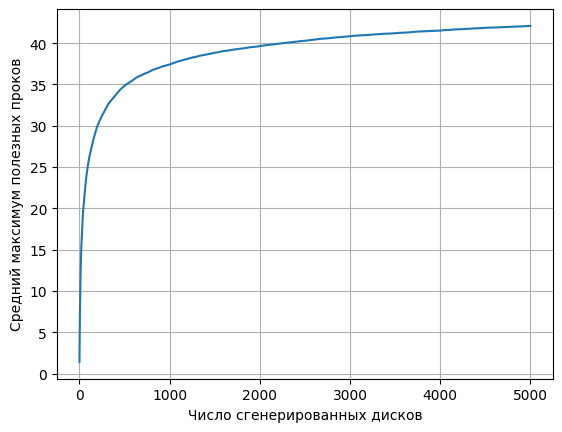

Рекомендуем остановиться примерно на артефакте с числом пользы 37 после 1019 дисков


In [44]:
usefull_main_stats = [None,
                      stats_map["hp"],
                      stats_map["atk"],
                      stats_map["def"],
                      stats_map["CR"],
                      stats_map["Ether DMG"],
                      stats_map["atk%"]]
usefull_sub_stats = {stats_map["atk%"], stats_map["CR"], stats_map["CD"]}

data_frame = pd.DataFrame(build_multi_curve())

In [64]:
qs = data_frame.quantile([i*200/n_discs for i in range(1, 11)])
qs.index = [[f"{i*200} дисков" for i in range(1, 11)]]
print(qs)

                    0
200 дисков   29.99680
400 дисков   33.71288
600 дисков   35.57304
800 дисков   36.69400
1000 дисков  37.42160
1200 дисков  38.10200
1400 дисков  38.60000
1600 дисков  39.03872
1800 дисков  39.35128
2000 дисков  39.64560


### Генерация дисков для аномальных персонажей

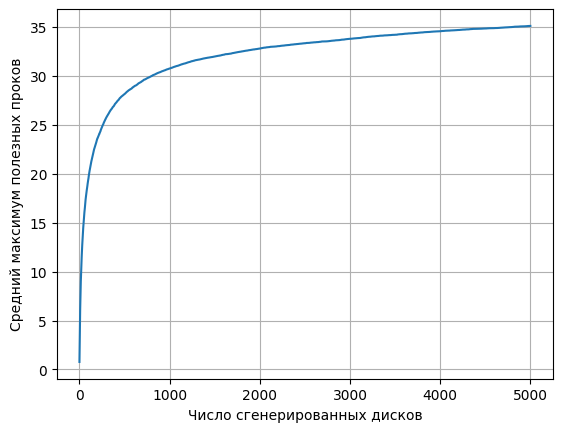

Рекомендуем остановиться примерно на артефакте с числом пользы 31


In [40]:
usefull_main_stats = [None,
                      stats_map["hp"],
                      stats_map["atk"],
                      stats_map["def"],
                      stats_map["AP"],
                      stats_map["Ether DMG"],
                      stats_map["AM"]]
usefull_sub_stats = {stats_map["atk%"], stats_map["AP"]}

build_multi_curve()

### Статистический анализ

χ² = 7.90, p-value = 0.5445


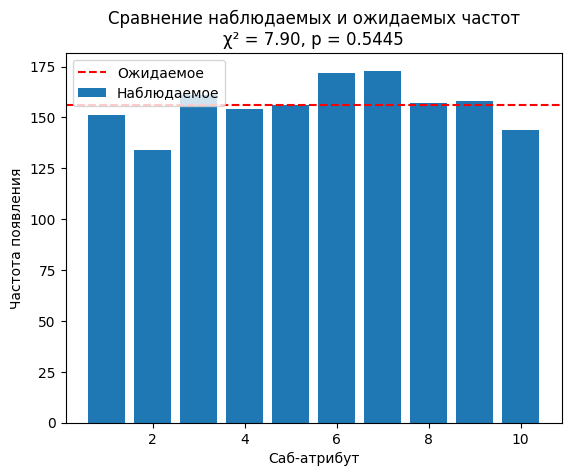

In [4]:
observed = np.array([151,
134,
161,
154,
156,
172,
173,
157,
158,
144])
expected = np.ones_like(observed) * observed.sum() / len(observed)

chi2, p_value = chisquare(f_obs=observed, f_exp=expected)

print(f"χ² = {chi2:.2f}, p-value = {p_value:.4f}")

plt.bar(range(1, 11), observed, label="Наблюдаемое")
plt.axhline(expected[0], color="red", linestyle="--", label="Ожидаемое")
plt.xlabel("Саб-атрибут")
plt.ylabel("Частота появления")
plt.title("Сравнение наблюдаемых и ожидаемых частот\n"
          f"χ² = {chi2:.2f}, p = {p_value:.4f}")
plt.legend()
plt.show()
#χ² = 7.61, p-value = 0.5744

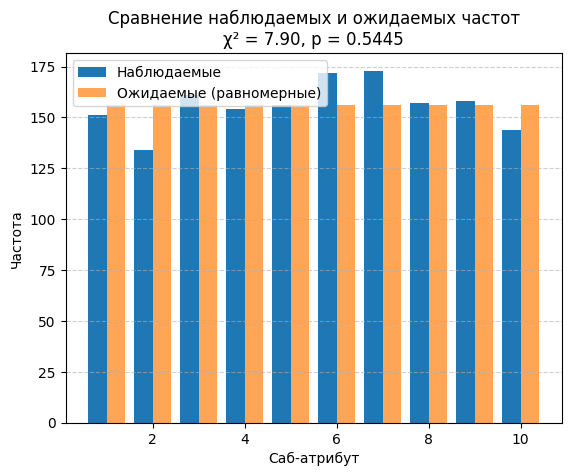

In [5]:
x = np.arange(1, len(observed) + 1)
plt.bar(x - 0.2, observed, width=0.4, label="Наблюдаемые")
plt.bar(x + 0.2, expected, width=0.4, label="Ожидаемые (равномерные)", alpha=0.7)

plt.xlabel("Саб-атрибут")
plt.ylabel("Частота")
plt.title("Сравнение наблюдаемых и ожидаемых частот\n"
          f"χ² = {chi2:.2f}, p = {p_value:.4f}")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

### 4 Disc

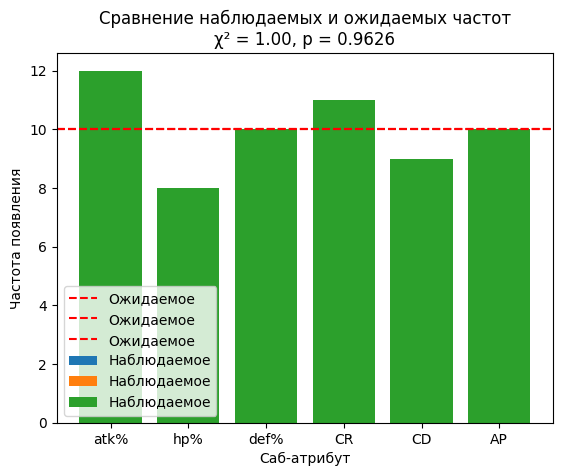

In [28]:
observed = np.array([12,
8,
10,
11,
9,
10])
observed_sum = observed.sum()

# может быть в виде весов или уже нормированных вероятностей
theoretical_probs = np.array([1,1,1,1,1,1])
theoretical_sum = theoretical_probs.sum()
# если у тебя веса, а не вероятности, нормируй:
if not isclose(theoretical_sum, 1.0):
    theoretical_probs = theoretical_probs / theoretical_sum

# ожидаемые частоты
expected = theoretical_probs * observed_sum

chi2, p_value = chisquare(f_obs=observed, f_exp=expected)

#print(f"χ² = {chi2:.2f}, p-value = {p_value:.4f}")
x = np.arange(1, len(observed) + 1)

plt.bar(range(1, 7), observed, label="Наблюдаемое")
plt.axhline(expected[0], color="red", linestyle="--", label="Ожидаемое")
plt.xticks(x, ["atk%", "hp%", "def%", "CR", "CD", "AP"])
plt.xlabel("Саб-атрибут")
plt.ylabel("Частота появления")
plt.title("Сравнение наблюдаемых и ожидаемых частот\n"
          f"χ² = {chi2:.2f}, p = {p_value:.4f}")
plt.legend()
plt.show()

### 5 Disc

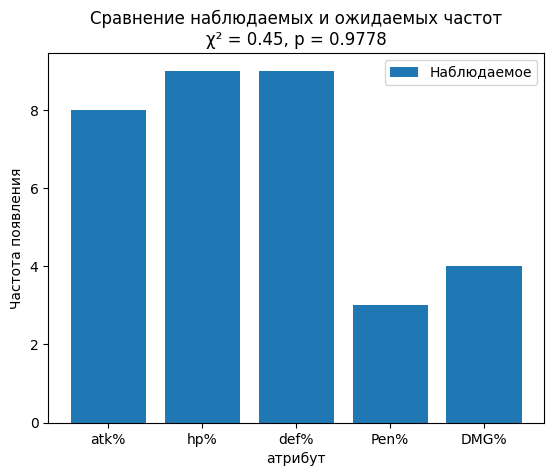

In [29]:
observed = np.array([8,
9,
9,
3,
20/5])
observed_sum = observed.sum()

# может быть в виде весов или уже нормированных вероятностей
theoretical_probs = np.array([2,2,2,1,1])
theoretical_sum = theoretical_probs.sum()
# если у тебя веса, а не вероятности, нормируй:
if not isclose(theoretical_sum, 1.0):
    theoretical_probs = theoretical_probs / theoretical_sum

# ожидаемые частоты
expected = theoretical_probs * observed_sum

chi2, p_value = chisquare(f_obs=observed, f_exp=expected)


x = np.arange(1, len(observed) + 1)
plt.bar(range(1, 6), observed, label="Наблюдаемое")
plt.xticks(x, ["atk%", "hp%", "def%", "Pen%", "DMG%"])
plt.xlabel("атрибут")
plt.ylabel("Частота появления")
plt.title("Сравнение наблюдаемых и ожидаемых частот\n"
          f"χ² = {chi2:.2f}, p = {p_value:.4f}")
plt.legend()
plt.show()

### 6 Disc

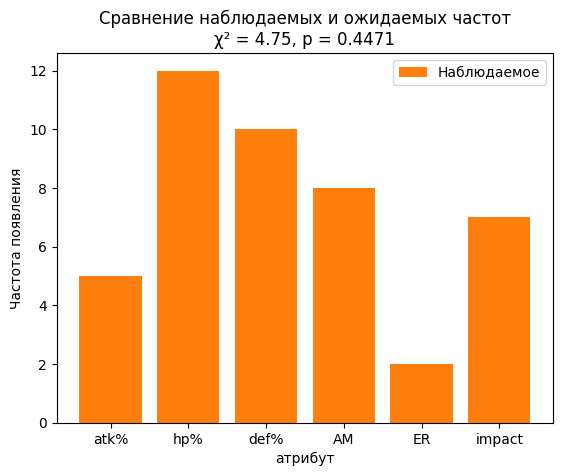

In [31]:
observed = np.array([5,
12,
10,
8,
2,
7])
observed_sum = observed.sum()

# может быть в виде весов или уже нормированных вероятностей
theoretical_probs = np.array([2,2,2,2,1,2])
theoretical_sum = theoretical_probs.sum()
# если у тебя веса, а не вероятности, нормируй:
if not isclose(theoretical_sum, 1.0):
    theoretical_probs = theoretical_probs / theoretical_sum

# ожидаемые частоты
expected = theoretical_probs * observed_sum

chi2, p_value = chisquare(f_obs=observed, f_exp=expected)


x = np.arange(1, len(observed) + 1)
plt.bar(range(1, 7), observed, label="Наблюдаемое")
plt.xticks(x, ["atk%", "hp%", "def%", "AM", "ER", "impact"])
plt.xlabel("атрибут")
plt.ylabel("Частота появления")
plt.title("Сравнение наблюдаемых и ожидаемых частот\n"
          f"χ² = {chi2:.2f}, p = {p_value:.4f}")
plt.legend()
plt.show()

### Tests (не используется)

In [9]:
from platform import python_version

print(python_version())

3.11.13


In [10]:
get_main_and_sub_stats(4)

(3, [5, 8, 0, 4], array([4, 1, 1, 2]))

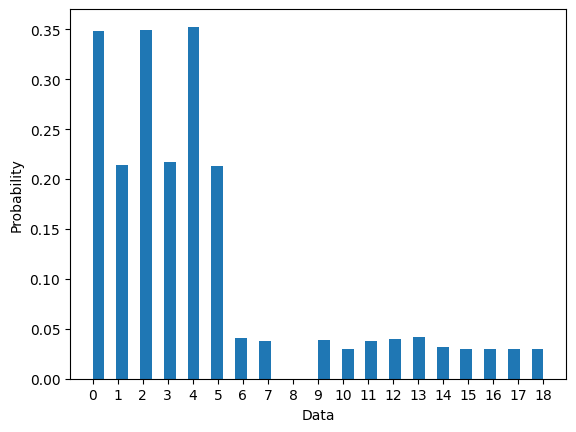

In [11]:
discs = random.choices(population=[1,2,3,4,5,6], k=100000)
stats = list(map(get_main_stat, discs))

plt.hist(stats, density=True, bins=38)  # density=False would make counts
plt.ylabel('Probability')
plt.xlabel('Data')
plt.xticks(np.arange(0, len(stats_map), 1.0))
plt.show()

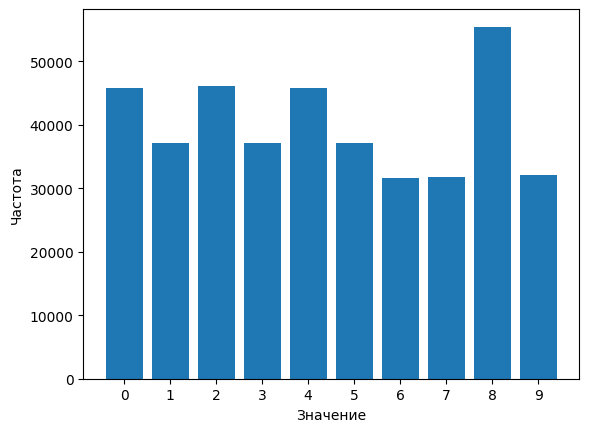

In [14]:
sub_stats_freq = [
    0
    for _ in range(10)
]

sub_rolls_freq = [
    0
    for _ in range(4)
]

for stat in stats:
    sub_stats, sub_rolls = get_sub_stats(stat)
    for j in range(n_substats):
        sub_stats_freq[sub_stats[j]] += 1
        sub_rolls_freq[j] += sub_rolls[j]

plt.bar(sub_stats_indexes, sub_stats_freq, width=0.8)  # width < 1 чтобы был зазор
plt.xticks(sub_stats_indexes)  # только целые подписи
plt.xlabel("Значение")
plt.ylabel("Частота")

plt.show()

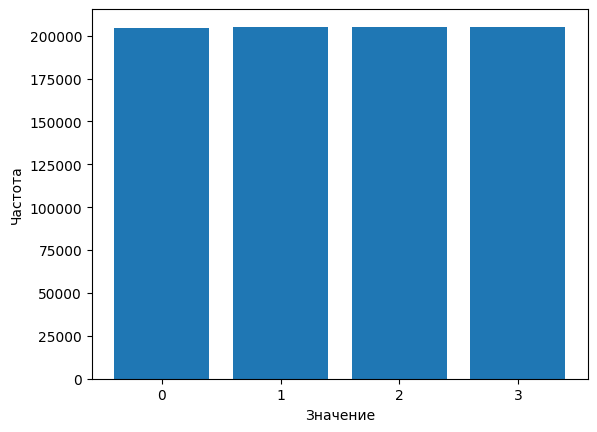

In [15]:
plt.bar([0, 1, 2, 3], sub_rolls_freq, width=0.8)  # width < 1 чтобы был зазор
plt.xticks([0, 1, 2, 3])  # только целые подписи
plt.xlabel("Значение")
plt.ylabel("Частота")

plt.show()

In [117]:
get_sub_stats(6)

([0, 8, 7, 2], [2, 0, 3, 2, 1])

In [103]:
sub_stats_freq

[48673, 35710, 49136, 35505, 49019, 35336, 28951, 29222, 59265, 29183]

In [4]:
def required_sample_size(E, confidence=0.95, p=None, k=None, correction='bonferroni'):
    """
    E: желаемая абсолютная погрешность (например 0.03)
    confidence: доверительная вероятность, например 0.95
    p: ожидаемая доля (если None, используется p=0.5 консервативно)
    k: число категорий (для множественной поправки). Если None, считаем для одной пропорции.
    correction: 'bonferroni' или None
    """
    if p is None:
        p = 0.5
    alpha = 1 - confidence
    if k is None:
        z = norm.ppf(1 - alpha/2)
    else:
        if correction == 'bonferroni':
            alpha_prime = alpha / k
            z = norm.ppf(1 - alpha_prime/2)
        else:
            z = norm.ppf(1 - alpha/2)
    n = (z**2 * p * (1 - p)) / (E**2)
    return math.ceil(n)

In [7]:
print("n (E=0.01, 95%, p unknown):", required_sample_size(0.1, confidence=0.95, p=0.5))

n (E=0.01, 95%, p unknown): 97


### Разные методы анализа (не используется)

In [19]:
delta = np.diff(avg_curve)  # разности между соседними точками
threshold = 0.00001
stop_index = np.where(delta < threshold)[0][0]  # первый раз, когда прирост < порог
print("Рекомендуем остановиться примерно на артефакте с числом пользы", round(avg_curve[stop_index]))

Рекомендуем остановиться примерно на артефакте с числом пользы 31


In [20]:
# Можно использовать скользящее среднее для сглаживания кривой, чтобы не реагировать на шум:
window = 50
threshold = 0.001
smoothed = np.convolve(avg_curve, np.ones(window)/window, mode='valid')
delta_smooth = np.diff(smoothed)
stop_index = np.where(delta_smooth < threshold)[0][0]
print("Рекомендуем остановиться примерно на артефакте с числом пользы", round(avg_curve[stop_index]))

Рекомендуем остановиться примерно на артефакте с числом пользы 38


In [21]:
# Методы анализа «точки насыщения»

def logistic(x, L, k, x0):
    return L / (1 + np.exp(-k*(x-x0)))

x = np.arange(len(avg_curve))
y = avg_curve
popt, _ = curve_fit(logistic, x, y, p0=[max(y), 0.001, 1000])
# popt = параметры L (максимум), k (наклон), x0 (середина)

In [22]:
L, k, x0 = popt
saturation_point = np.log(19)/k + x0  # 95% от L
print("Рекомендуем остановиться примерно на артефакте с числом пользы", round(avg_curve[int(saturation_point)]))

Рекомендуем остановиться примерно на артефакте с числом пользы 36


In [23]:
import pandas as pd

df = pd.DataFrame({'avg_max': avg_curve})
df['rolling_mean'] = df['avg_max'].rolling(50).mean()
df['delta'] = df['rolling_mean'].diff()
stop_index = df[df['delta'] < 0.01].index[0]
print("Рекомендуем остановиться примерно на артефакте с числом пользы", round(avg_curve[stop_index]))

Рекомендуем остановиться примерно на артефакте с числом пользы 32
